# Feature Engineering & Proxy Target Construction

This notebook demonstrates the complete feature engineering pipeline for the credit risk model:

1. **Temporal features** extracted from transaction timestamps
2. **Customer-level aggregate features** (RFM and behavioral)
3. **Proxy target variable** via RFM + KMeans clustering
4. **Weight of Evidence (WoE) / Information Value (IV)** analysis
5. **Full sklearn Pipeline** for reproducible transformations

## 1. Setup

In [1]:
import sys
from pathlib import Path

proj_root = Path.cwd().resolve().parent
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from src.data_processing import (
    build_feature_pipeline,
    calculate_rfm,
    compute_all_iv,
    engineer_features,
)
from src.data_loader import load_data

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

2026-07-15 14:35:29,509 [INFO] Embedded WoE/IV utilities into data_processing module


## 2. Load Raw Data

In [2]:
raw_path = proj_root / "data" / "raw" / "data.csv"
df = load_data(raw_path)
print(f"Shape: {df.shape}")
df.head()

Shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,False
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,False
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,False
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,False
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,False


In [3]:
print("Data types:")
print(df.dtypes)
print(f"\nUnique customers: {df['CustomerId'].nunique()}")
print(f"Date range: {df['TransactionStartTime'].min()} to {df['TransactionStartTime'].max()}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Data types:
TransactionId                        object
BatchId                              object
AccountId                            object
SubscriptionId                       object
CustomerId                           object
CurrencyCode                       category
CountryCode                        category
ProviderId                         category
ProductId                          category
ProductCategory                    category
ChannelId                          category
Amount                              float64
Value                                 int64
TransactionStartTime    datetime64[ns, UTC]
PricingStrategy                    category
FraudResult                            bool
dtype: object

Unique customers: 3742
Date range: 2018-11-15 02:18:49+00:00 to 2019-02-13 10:01:28+00:00

Missing values:
Series([], dtype: int64)


## 3. Temporal Feature Engineering

Extract time-based features from `TransactionStartTime`.

In [4]:
%matplotlib inline

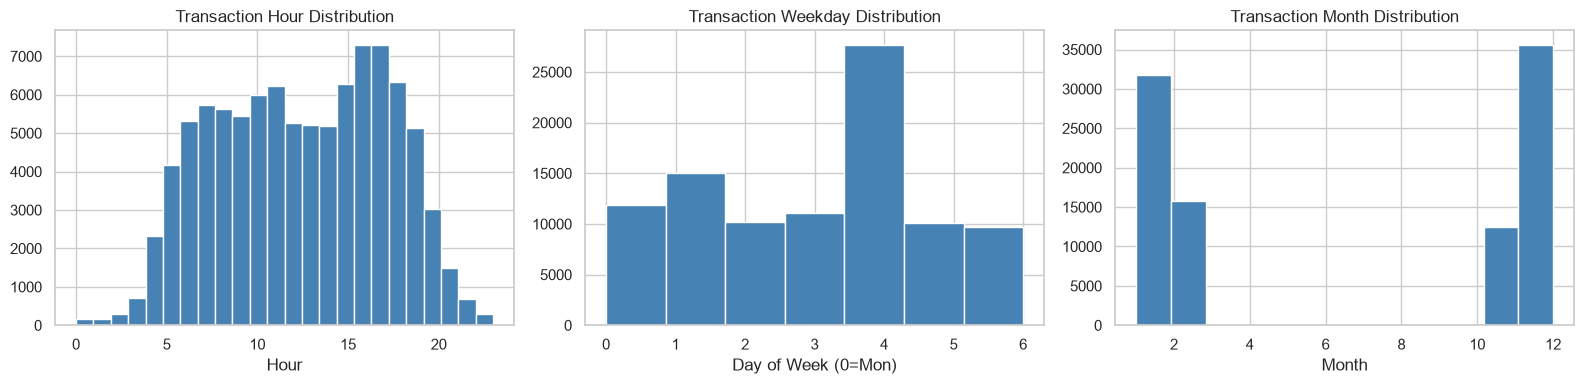

In [5]:
df["TransactionHour"] = df["TransactionStartTime"].dt.hour
df["TransactionDay"] = df["TransactionStartTime"].dt.day
df["TransactionMonth"] = df["TransactionStartTime"].dt.month
df["TransactionYear"] = df["TransactionStartTime"].dt.year
df["TransactionWeekday"] = df["TransactionStartTime"].dt.weekday

temporal_cols = ["TransactionHour", "TransactionDay", "TransactionMonth",
                 "TransactionYear", "TransactionWeekday"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df["TransactionHour"].hist(bins=24, ax=axes[0], color="steelblue")
axes[0].set_title("Transaction Hour Distribution")
axes[0].set_xlabel("Hour")

df["TransactionWeekday"].hist(bins=7, ax=axes[1], color="steelblue")
axes[1].set_title("Transaction Weekday Distribution")
axes[1].set_xlabel("Day of Week (0=Mon)")

df["TransactionMonth"].hist(bins=12, ax=axes[2], color="steelblue")
axes[2].set_title("Transaction Month Distribution")
axes[2].set_xlabel("Month")

plt.tight_layout()
plt.show()

## 4. Customer-Level Aggregate Features

Compute per-customer statistics from transaction history.

In [6]:
customer_agg = (
    df.groupby("CustomerId")
    .agg(
        TotalTransactionAmount=("Amount", "sum"),
        AvgTransactionAmount=("Amount", "mean"),
        TransactionCount=("TransactionId", "count"),
        StdTransactionAmount=("Amount", "std"),
        FirstTransaction=("TransactionStartTime", "min"),
        LastTransaction=("TransactionStartTime", "max"),
    )
    .reset_index()
)

customer_agg["StdTransactionAmount"] = customer_agg["StdTransactionAmount"].fillna(0)

snapshot_date = pd.Timestamp.now(tz="UTC")
customer_agg["Recency"] = (snapshot_date - customer_agg["LastTransaction"]).dt.days
customer_agg["CustomerTenureDays"] = (
    customer_agg["LastTransaction"] - customer_agg["FirstTransaction"]
).dt.days

print(f"Customer aggregates shape: {customer_agg.shape}")
customer_agg.head(10)

Customer aggregates shape: (3742, 9)


,CustomerId,TotalTransactionAmount,AvgTransactionAmount,TransactionCount,StdTransactionAmount,FirstTransaction,LastTransaction,Recency,CustomerTenureDays
0,CustomerId_1,-10000.0,-10000.000000,1,0.000000,2018-11-21 16:49:14+00:00,2018-11-21 16:49:14+00:00,2792,0
1,CustomerId_10,-10000.0,-10000.000000,1,0.000000,2018-11-21 16:49:09+00:00,2018-11-21 16:49:09+00:00,2792,0
2,CustomerId_1001,20000.0,4000.000000,5,6558.963333,2018-11-16 07:53:19+00:00,2018-11-16 08:20:39+00:00,2798,0
3,CustomerId_1002,4225.0,384.090909,11,560.498966,2018-11-15 18:50:09+00:00,2019-01-18 10:05:00+00:00,2735,63
4,CustomerId_1003,20000.0,3333.333333,6,6030.478146,2019-02-01 14:58:07+00:00,2019-02-01 15:04:51+00:00,2720,0
5,CustomerId_1004,2000.0,2000.000000,1,0.000000,2018-12-22 18:14:31+00:00,2018-12-22 18:14:31+00:00,2761,0
6,CustomerId_1005,48800.0,5422.222222,9,5983.681513,2018-12-28 08:44:36+00:00,2018-12-28 13:08:44+00:00,2755,0
7,CustomerId_1006,1000.0,1000.000000,1,0.000000,2018-12-11 07:28:04+00:00,2018-12-11 07:28:04+00:00,2773,0
8,CustomerId_1007,28000.0,28000.000000,1,0.000000,2018-11-24 06:35:26+00:00,2018-11-24 06:35:26+00:00,2790,0
9,CustomerId_1008,20000.0,10000.000000,2,0.000000,2018-12-09 13:14:07+00:00,2018-12-09 13:15:46+00:00,2774,0


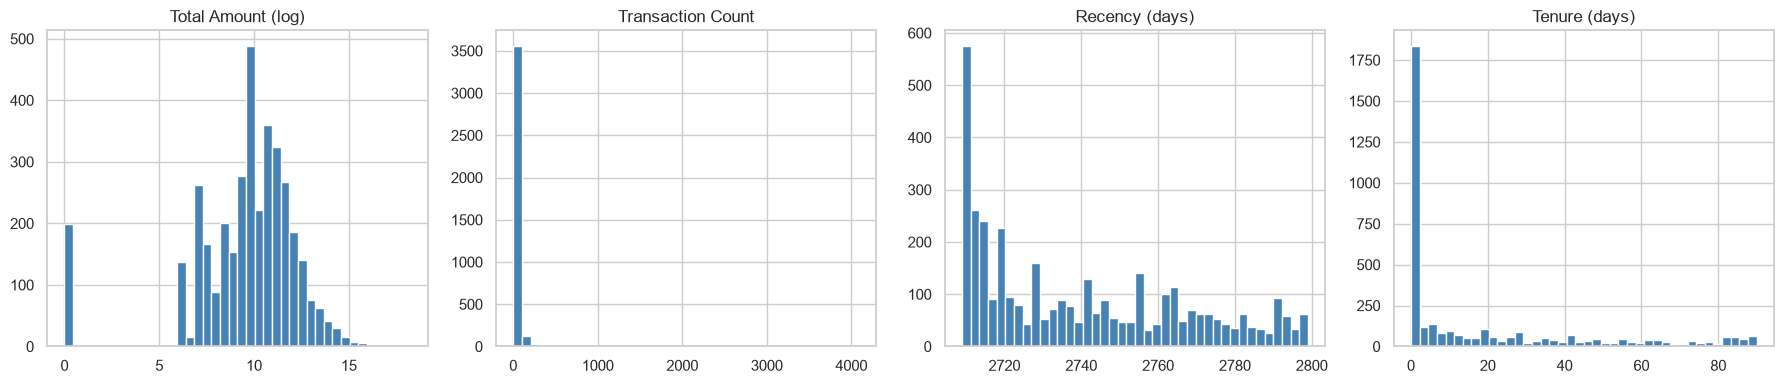

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

customer_agg["TotalTransactionAmount"].clip(lower=0).apply(np.log1p).hist(
    bins=40, ax=axes[0], color="steelblue"
)
axes[0].set_title("Total Amount (log)")

customer_agg["TransactionCount"].hist(bins=40, ax=axes[1], color="steelblue")
axes[1].set_title("Transaction Count")

customer_agg["Recency"].hist(bins=40, ax=axes[2], color="steelblue")
axes[2].set_title("Recency (days)")

customer_agg["CustomerTenureDays"].hist(bins=40, ax=axes[3], color="steelblue")
axes[3].set_title("Tenure (days)")

plt.tight_layout()
plt.show()

## 5. RFM Calculation

Recency, Frequency, and Monetary values form the basis for customer segmentation.

In [8]:
rfm = calculate_rfm(df)
print(f"RFM table shape: {rfm.shape}")
rfm.describe().round(2)

RFM table shape: (3742, 7)


,Recency,Frequency,Monetary,AvgMonetary,FirstTransaction,LastTransaction
count,3742.00,3742.00,3.742000e+03,3742.00,3742,3742
mean,2739.55,25.56,2.531025e+05,18756.12,2018-12-25 03:45:21.322822144,2019-01-13 09:52:30.341795840
min,2709.00,1.00,5.000000e+01,50.00,2018-11-15 02:18:49,2018-11-15 03:35:10
25%,2714.00,2.00,6.500000e+03,1160.66,2018-11-30 12:52:17.500000,2018-12-21 19:33:13.750000128
50%,2733.00,7.00,3.200000e+04,3950.00,2018-12-22 23:43:50.500000,2019-01-19 19:16:13
75%,2762.00,20.00,1.020600e+05,7096.04,2019-01-17 22:52:00.500000,2019-02-08 07:36:27.249999872
max,2799.00,4091.00,1.049000e+08,8601821.14,2019-02-13 09:40:18,2019-02-13 10:01:28
std,27.11,96.93,2.715877e+06,167452.89,NaN,NaN


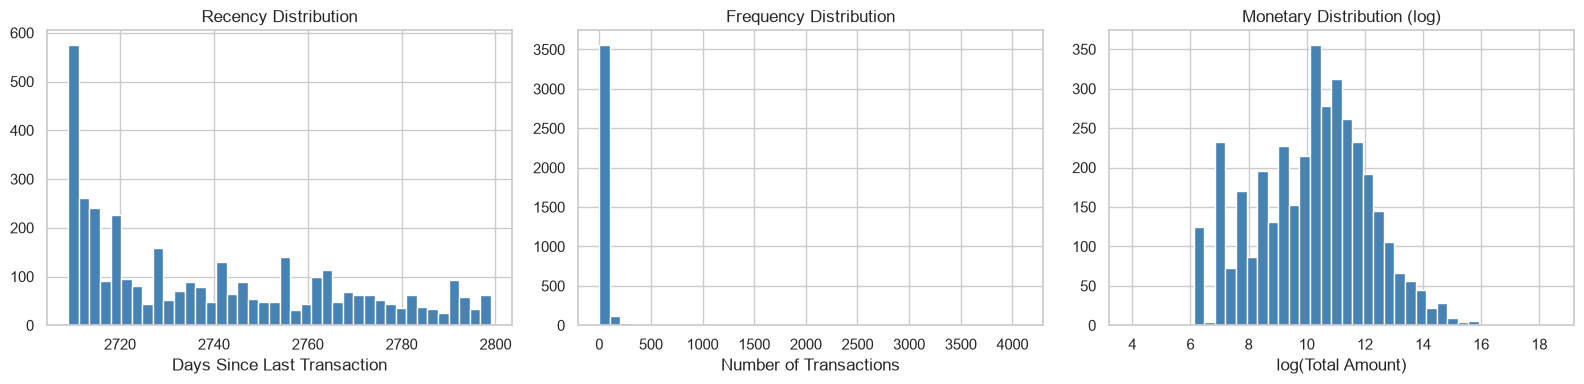

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(rfm["Recency"], bins=40, color="steelblue")
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days Since Last Transaction")

axes[1].hist(rfm["Frequency"], bins=40, color="steelblue")
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Transactions")

axes[2].hist(rfm["Monetary"].clip(lower=0).apply(np.log1p), bins=40, color="steelblue")
axes[2].set_title("Monetary Distribution (log)")
axes[2].set_xlabel("log(Total Amount)")

plt.tight_layout()
plt.show()

## 6. Proxy Target Variable via KMeans Clustering

Since the dataset has no explicit default label, we create a **proxy variable** for credit risk:

1. Scale RFM features
2. Cluster into 3 groups with KMeans (random_state=42)
3. Identify the least-engaged cluster (high recency, low frequency, low monetary)
4. Label as `is_high_risk = 1`

In [ ]:
features = ["Recency", "Frequency", "Monetary"]
X_rfm = rfm[features].fillna(rfm[features].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rfm)

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = (
    rfm.groupby("Cluster")
    .agg({"Recency": "mean", "Frequency": "mean", "Monetary": "mean", "CustomerId": "count"})
    .round(2)
    .rename(columns={"CustomerId": "Count"})
)
print("Cluster Summary:")
cluster_summary

In [ ]:
risk_cluster = cluster_summary.sort_values(
    by=["Recency", "Frequency", "Monetary"], ascending=[False, True, True]
).index[0]

print(f"High-risk cluster: {risk_cluster}")
rfm["is_high_risk"] = (rfm["Cluster"] == risk_cluster).astype(int)
print(f"\nTarget distribution:\n{rfm['is_high_risk'].value_counts()}")

High-risk cluster: 1

Target distribution:
is_high_risk
0    2311
1    1431
Name: count, dtype: int64


2026-07-15 14:32:29,969 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\teMelkishi\AppData\Local\Temp\ipykernel_28412\2916268621.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
2026-07-15 14:32:29,979 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


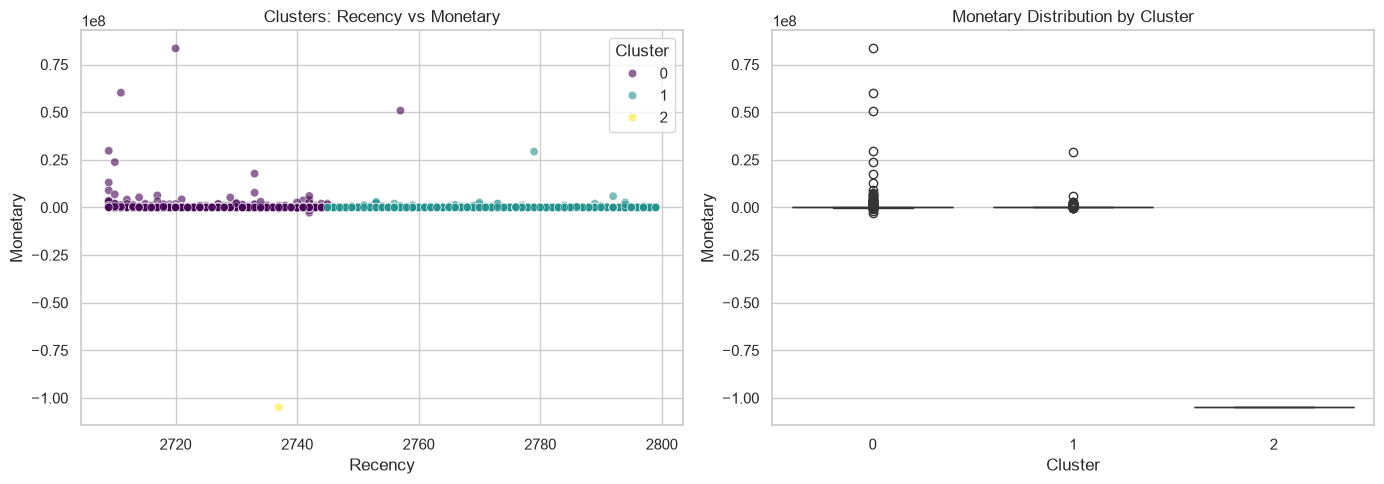

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=rfm, x="Recency", y="Monetary", hue="Cluster",
    palette="viridis", ax=axes[0], alpha=0.6
)
axes[0].set_title("Clusters: Recency vs Monetary")

sns.boxplot(
    data=rfm, x="Cluster", y="Monetary", palette="viridis", ax=axes[1]
)
axes[1].set_title("Monetary Distribution by Cluster")

plt.tight_layout()
plt.show()

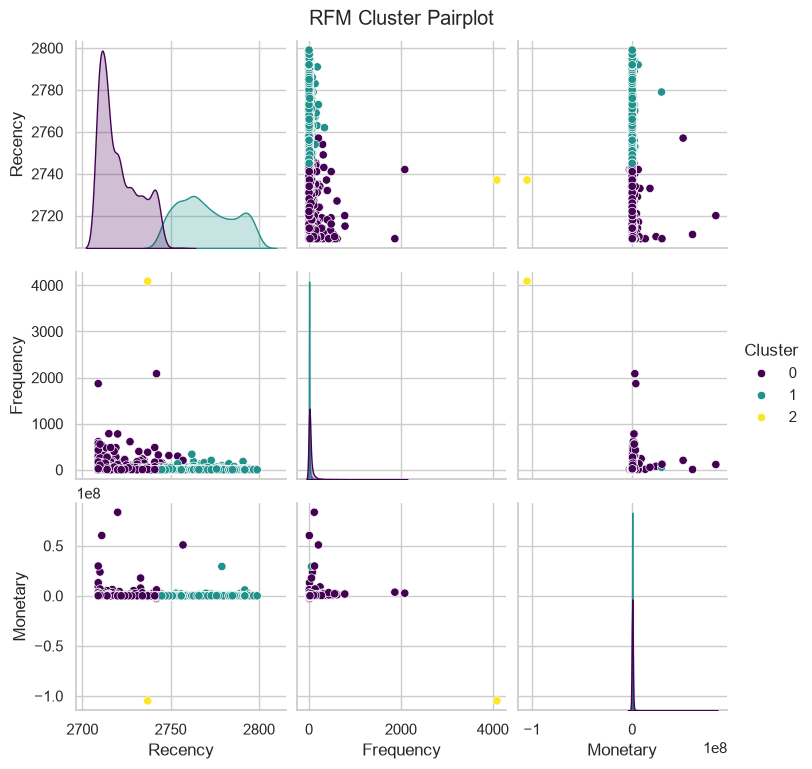

In [ ]:
sns.pairplot(
    rfm, vars=["Recency", "Frequency", "Monetary"],
    hue="Cluster", palette="viridis", diag_kind="kde"
)
plt.suptitle("RFM Cluster Pairplot", y=1.02)
plt.show()

## 7. Merge Proxy Target Back to Transaction Data

In [ ]:
df = df.merge(
    rfm[["CustomerId", "is_high_risk"]], on="CustomerId", how="left"
)
print(f"Transactions with target: {df['is_high_risk'].notna().sum()}/{len(df)}")
print(f"Target distribution (per-transaction):")
print(df["is_high_risk"].value_counts(normalize=True).round(3))

Transactions with target: 95662/95662
Target distribution (per-transaction):
is_high_risk
0    0.884
1    0.116
Name: proportion, dtype: float64


## 8. Weight of Evidence (WoE) / Information Value (IV)

IV measures the predictive power of each feature for the target variable.

| IV Range | Predictive Power |
|----------|------------------|
| < 0.02 | Useless |
| 0.02 - 0.1 | Weak |
| 0.1 - 0.3 | Medium |
| 0.3 - 0.5 | Strong |
| > 0.5 | Very Strong |

In [ ]:
categorical_cols = ["ProviderId", "ProductId", "ProductCategory", "ChannelId"]
numerical_cols_for_iv = [
    "Amount", "Value", "PricingStrategy", "TransactionHour",
    "TransactionDay", "TransactionMonth",
]

iv_results = compute_all_iv(
    df,
    features=categorical_cols + numerical_cols_for_iv,
    categorical_cols=categorical_cols,
    numerical_cols=numerical_cols_for_iv,
    target="is_high_risk",
)
print("Information Value Results:")
iv_results

TypeError: Categorical is not ordered for operation min
you can use .as_ordered() to change the Categorical to an ordered one


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = {
    "Useless": "gray", "Weak": "salmon",
    "Medium": "orange", "Strong": "green", "Very Strong": "darkgreen"
}
bar_colors = [colors[p] for p in iv_results["predictive_power"]]
ax.barh(iv_results["feature"], iv_results["iv"], color=bar_colors)
ax.set_xlabel("Information Value")
ax.set_title("Feature Predictive Power (IV)")
ax.axvline(x=0.1, color="red", linestyle="--", alpha=0.5, label="Medium threshold")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Full sklearn Pipeline

Chain all transformations into a reproducible pipeline:
- Feature engineering (temporal + aggregates)
- Missing value imputation
- Outlier capping (IQR)
- WoE encoding for categoricals
- One-hot encoding
- Standard scaling

In [ ]:
target_col = "is_high_risk"

num_cols = (
    df.select_dtypes(include=["number"])
    .columns.drop(target_col, errors="ignore")
    .tolist()
)
cat_cols = ["ProviderId", "ProductId", "ProductCategory", "ChannelId"]

print(f"Numerical columns ({len(num_cols)}): {num_cols}")
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")

In [ ]:
pipeline = build_feature_pipeline(
    target_col=target_col,
    scaling_method="standard",
    categorical_cols=cat_cols,
    numerical_cols=num_cols,
)

print("Pipeline steps:")
for name, step in pipeline.steps:
    print(f"  - {name}: {step.__class__.__name__}")

In [ ]:
processed_df = pipeline.fit_transform(df, y=df[target_col])
print(f"Processed shape: {processed_df.shape}")
processed_df.head()

## 10. Save Processed Data and Pipeline

In [ ]:
import joblib

processed_dir = proj_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
processed_path = processed_dir / "processed_data.csv"

processed_df.to_csv(processed_path, index=False)
print(f"Processed data saved to: {processed_path}")
print(f"Shape: {processed_df.shape}")

models_dir = proj_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)
pipeline_path = models_dir / "pipeline.joblib"

joblib.dump(pipeline, pipeline_path)
print(f"Pipeline saved to: {pipeline_path}")

## 11. Summary of Key Insights

1. **Temporal patterns**: Transactions peak at specific hours and weekdays, providing useful behavioral signals.
2. **Customer heterogeneity**: Wide variance in transaction counts, total amounts, and recency indicates distinct customer segments.
3. **RFM clustering**: KMeans successfully separates customers into 3 groups; the least-engaged cluster (high recency, low frequency/monetary) serves as a plausible high-risk proxy.
4. **IV analysis**: ProductCategory and ChannelId show the strongest predictive power for the proxy target.
5. **Pipeline reproducibility**: The full sklearn pipeline ensures consistent feature transformations between training and inference.